***Data Analusis of ChatBot Interactions***

In [5]:
import pandas as pd

df = pd.read_csv("interaction_logs.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()

,session_id,timestamp,user_query,predicted_intent,confidence_score,response_time_ms,resolved,satisfaction_score,escalated_to_human
0,1546,2026-01-20 22:51:00,I forgot my password,Account,0.8814,630,True,4,False
1,1211,2025-11-25 23:26:00,Is the certificate recognised by companies?,Certificate,0.9182,371,True,4,False
2,1247,2025-10-15 11:27:00,Is the certificate recognised by companies?,Certificate,0.8789,533,True,3,False
3,1420,2025-11-07 13:10:00,Who are the instructors?,Instructor,0.8789,526,True,4,False
4,1032,2026-03-29 18:26:00,Tell me about Data Science course,Course,0.9692,844,True,5,False


In [7]:
# KPI Metrics
rated = df[df["satisfaction_score"].notna()]

avg_confidence = df["confidence_score"].mean()

avg_rating = rated["satisfaction_score"].mean()

satisfaction_rate = (
    (rated["satisfaction_score"] >= 4).mean() * 100
)

total_interactions = len(df)

unique_sessions = df["session_id"].nunique()

print("Total Interactions:", total_interactions)
print("Unique Sessions:", unique_sessions)
print("Average Confidence:", round(avg_confidence*100,2),"%")
print("Average Rating:", round(avg_rating,2))
print("Satisfaction Rate:", round(satisfaction_rate,2),"%")

Total Interactions: 600
Unique Sessions: 600
Average Confidence: 88.24 %
Average Rating: 3.86
Satisfaction Rate: 64.17 %


In [8]:
df["predicted_intent"].value_counts()

predicted_intent
Account        50
Certificate    50
Instructor     50
Course         50
Refund         50
Technical      50
Farewell       50
Payment        50
Greeting       50
Schedule       50
Enrollment     50
Discount       50
Name: count, dtype: int64

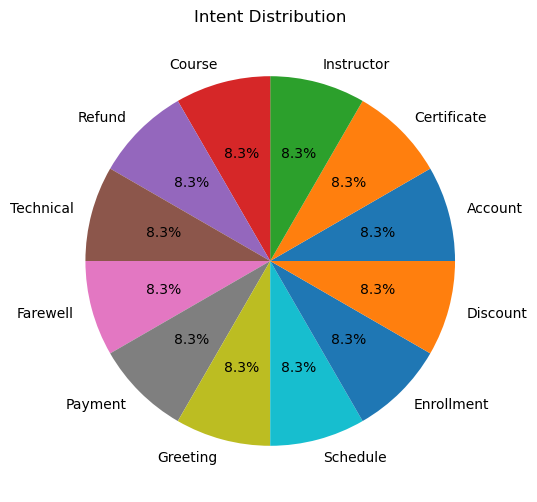

In [9]:
import matplotlib.pyplot as plt

intent_counts = df["predicted_intent"].value_counts()

plt.figure(figsize=(8,6))

intent_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Intent Distribution")

plt.ylabel("")

plt.show()

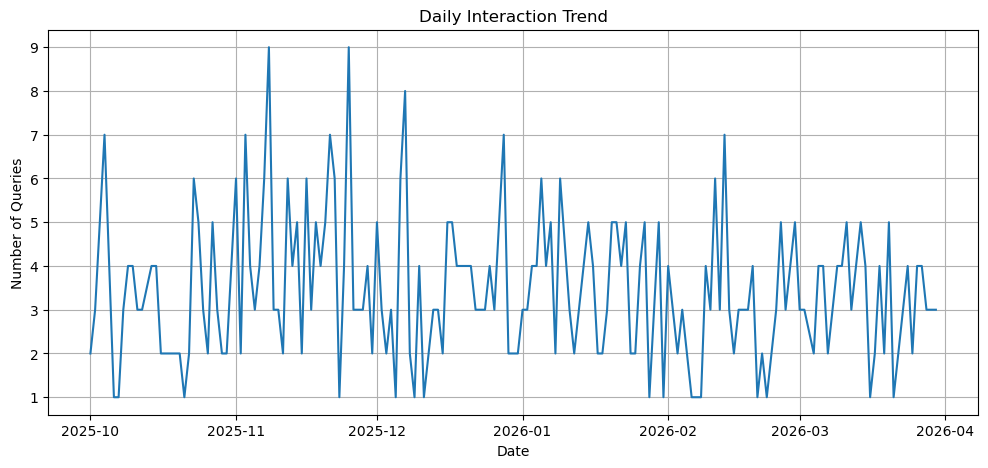

In [10]:
daily = (
    df.groupby(
        df["timestamp"].dt.date
    )
    .size()
)

plt.figure(figsize=(12,5))

daily.plot()

plt.title("Daily Interaction Trend")

plt.xlabel("Date")

plt.ylabel("Number of Queries")

plt.grid(True)

plt.show()

In [11]:
df["hour"] = df["timestamp"].dt.hour

hourly = df.groupby("hour").size()

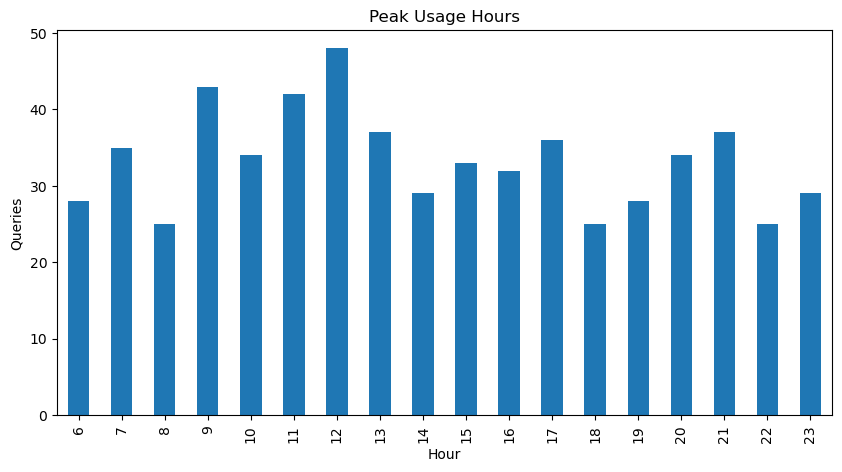

In [12]:
plt.figure(figsize=(10,5))

hourly.plot(kind="bar")

plt.title("Peak Usage Hours")

plt.xlabel("Hour")

plt.ylabel("Queries")

plt.show()

In [15]:
# Confidence by Intent
confidence_by_intent = (
    df.groupby("predicted_intent")
      ["confidence_score"]
      .mean()
      .sort_values()
)

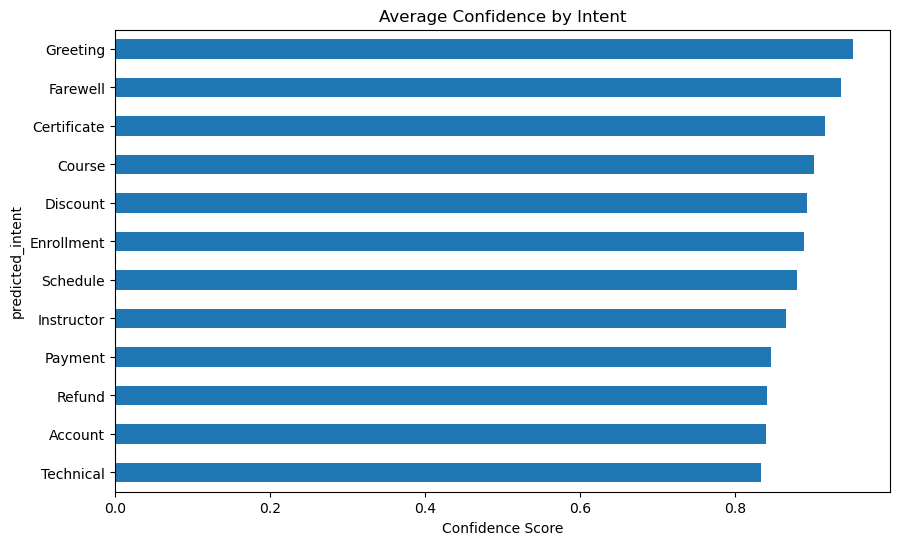

In [16]:
plt.figure(figsize=(10,6))

confidence_by_intent.plot(
    kind="barh"
)

plt.title(
    "Average Confidence by Intent"
)

plt.xlabel("Confidence Score")

plt.show()

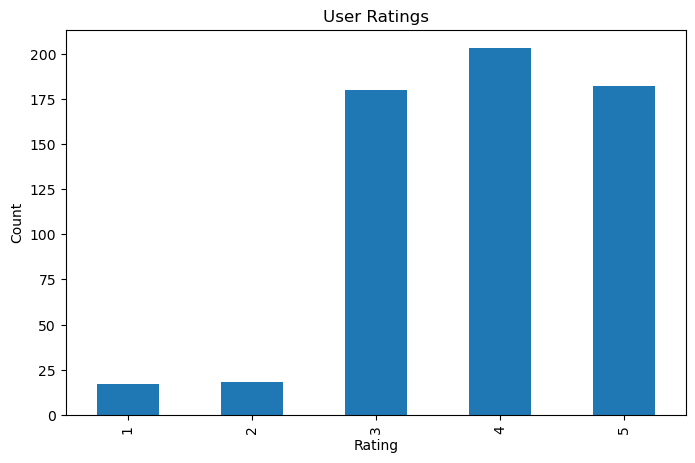

In [18]:
# Rating Distribution
ratings = (
    rated["satisfaction_score"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(8,5))

ratings.plot(kind="bar")

plt.title("User Ratings")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

In [19]:
# Weekly Traffic Pattern
df["weekday"] = (
    df["timestamp"]
      .dt.day_name()
)
weekly = (
    df.groupby("weekday")
      .size()
)
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly = weekly.reindex(order)

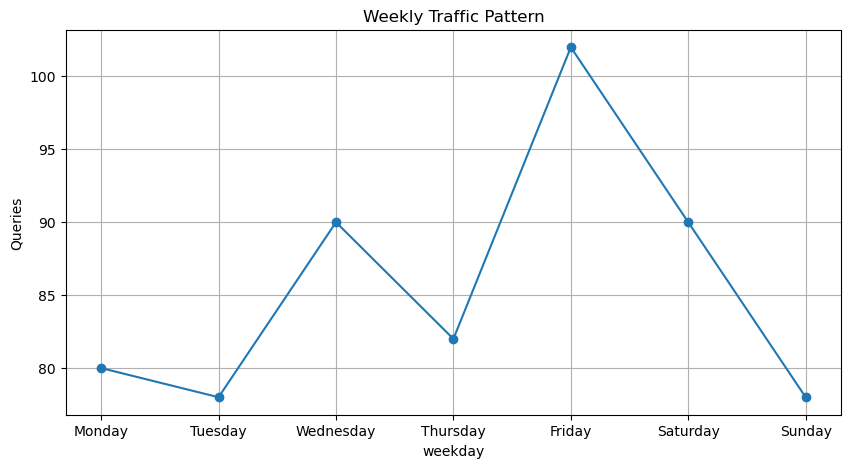

In [20]:
plt.figure(figsize=(10,5))

weekly.plot(marker="o")

plt.title("Weekly Traffic Pattern")

plt.ylabel("Queries")

plt.grid(True)

plt.show()

In [21]:
# Fallback Analysis
fallbacks = df[
    df["predicted_intent"] == "fallback"
]
fallback_rate = (
    len(fallbacks)
    /
    len(df)
    * 100
)
print(
    "Fallback Queries:",
    len(fallbacks)
)

print(
    "Fallback Rate:",
    round(fallback_rate,2),
    "%"
)

Fallback Queries: 0
Fallback Rate: 0.0 %


In [22]:
# Business Impact Analysis
queries_per_session = (
    len(df)
    /
    df["session_id"].nunique()
)

business_summary = pd.DataFrame({
    "Metric":[
        "Queries per Session",
        "Average Confidence",
        "Average Rating",
        "Satisfaction Rate"
    ],
    "Value":[
        round(queries_per_session,2),
        round(avg_confidence*100,2),
        round(avg_rating,2),
        round(satisfaction_rate,2)
    ]
})

business_summary

,Metric,Value
0,Queries per Session,1.00
1,Average Confidence,88.24
2,Average Rating,3.86
3,Satisfaction Rate,64.17
